# BBox Training Pipeline Visualization

This notebook visualizes one random training sample through the same bounding-box pipeline used in training:
1. original image
2. ground-truth bbox overlay
3. resized model input tensor view
4. inference using exported best model
5. predicted-vs-ground-truth bbox diagnostics

## Setup

In [38]:
import os
import sys
import random
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from torchvision import transforms

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "training":
    PROJECT_ROOT = PROJECT_ROOT.parent.parent
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from data.bbox_dataset import TennisBBoxDataset
from models.bbox_detection import BBoxDetectionModel

ROOT_DIR = PROJECT_ROOT / "datasets/orvile/tennis-player-actions-dataset/versions/1/Tennis Player Actions Dataset for Human Pose Estimation"
ANNOTATION_FILES = [
    "annotations/backhand.json",
    "annotations/forehand.json",
    "annotations/ready_position.json",
    "annotations/serve.json",
]
INPUT_SIZE = (256, 256)

# SEED = 42
# random.seed(SEED)
# np.random.seed(SEED)
# torch.manual_seed(SEED)

print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset root: {ROOT_DIR}")

Project root: /Users/hanyiliu/Documents/GitHub/tennis-pose-detection
Dataset root: /Users/hanyiliu/Documents/GitHub/tennis-pose-detection/datasets/orvile/tennis-player-actions-dataset/versions/1/Tennis Player Actions Dataset for Human Pose Estimation


## 1) Original Image + Ground-Truth BBox

Random sample with COCO ground-truth bbox overlay in original image coordinates.

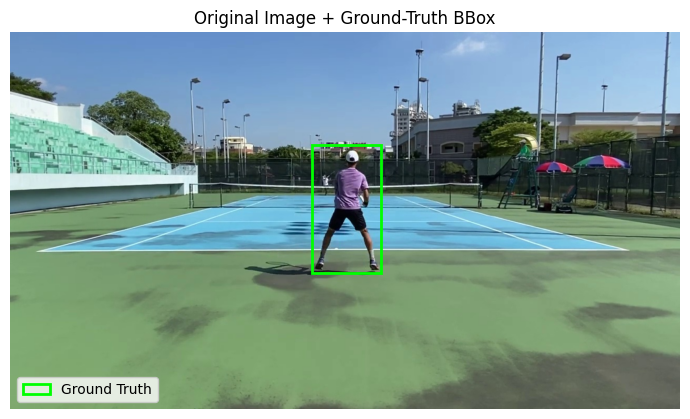

Sample index: 1492
Image path: /Users/hanyiliu/Documents/GitHub/tennis-pose-detection/datasets/orvile/tennis-player-actions-dataset/versions/1/Tennis Player Actions Dataset for Human Pose Estimation/images/ready_position/R_493.jpeg
Image size (W,H): (1280, 720)
Ground-truth bbox [x, y, w, h]: [577. 216. 131. 244.]


In [39]:
dataset_for_visual = TennisBBoxDataset(
    root_dir=str(ROOT_DIR),
    annotation_files=ANNOTATION_FILES,
    transform=None,
)

sample_idx = random.randrange(len(dataset_for_visual))
sample = dataset_for_visual.samples[sample_idx]

img_path = sample["img_path"]
gt_bbox = np.array(sample["bbox"], dtype=np.float32)  # [x, y, w, h] in pixels

original_img = Image.open(img_path).convert("RGB")
img_w, img_h = original_img.size

fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(original_img)
rect_gt = patches.Rectangle(
    (gt_bbox[0], gt_bbox[1]),
    gt_bbox[2],
    gt_bbox[3],
    linewidth=2,
    edgecolor="lime",
    facecolor="none",
    label="Ground Truth",
)
ax.add_patch(rect_gt)
ax.set_title("Original Image + Ground-Truth BBox")
ax.axis("off")
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

print(f"Sample index: {sample_idx}")
print(f"Image path: {img_path}")
print(f"Image size (W,H): ({img_w}, {img_h})")
print("Ground-truth bbox [x, y, w, h]:", gt_bbox)

## 2) Transformed Model Input

Training transform stage: `Resize(256,256)` + tensor conversion.

Transformed image tensor shape: (3, 256, 256)
Ground-truth normalized bbox [x/W, y/H, w/W, h/H]: [0.45078126 0.3        0.10234375 0.33888888]


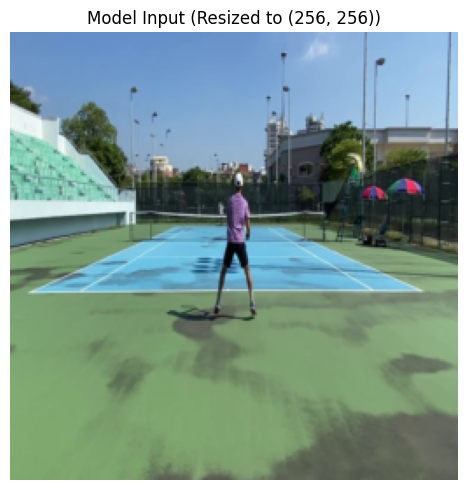

In [40]:
model_transform = transforms.Compose([
    transforms.Resize(INPUT_SIZE),
    transforms.ToTensor(),
])

dataset_for_model = TennisBBoxDataset(
    root_dir=str(ROOT_DIR),
    annotation_files=ANNOTATION_FILES,
    transform=model_transform,
)

img_tensor, gt_bbox_norm = dataset_for_model[sample_idx]
img_tensor_batch = img_tensor.unsqueeze(0)

img_resized_np = img_tensor.permute(1, 2, 0).numpy()

print("Transformed image tensor shape:", tuple(img_tensor.shape))
print("Ground-truth normalized bbox [x/W, y/H, w/W, h/H]:", gt_bbox_norm.numpy())

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(img_resized_np)
ax.set_title(f"Model Input (Resized to {INPUT_SIZE})")
ax.axis("off")
plt.tight_layout()
plt.show()

## 3) Inference with Exported Best Model

Loads bbox model from `exports/` first, with checkpoint fallback.

In [41]:
def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

export_ckpt = PROJECT_ROOT / "exports" / "bbox_best.pt"
fallback_ckpt = PROJECT_ROOT / "checkpoints" / "bbox_best.pt"
if export_ckpt.exists():
    checkpoint_path = export_ckpt
elif fallback_ckpt.exists():
    checkpoint_path = fallback_ckpt
else:
    raise FileNotFoundError(f"No bbox checkpoint found. Checked: {export_ckpt} and {fallback_ckpt}")

device = get_device()
checkpoint = torch.load(checkpoint_path, map_location=device)
if isinstance(checkpoint, dict) and "model_state" in checkpoint:
    state_dict = checkpoint["model_state"]
else:
    state_dict = checkpoint

bbox_model = BBoxDetectionModel().to(device)
bbox_model.load_state_dict(state_dict)
bbox_model.eval()

with torch.no_grad():
    pred_bbox_norm = bbox_model(img_tensor_batch.to(device))[0].detach().cpu().numpy()

pred_bbox_norm = np.clip(pred_bbox_norm, 0.0, 1.0)
pred_bbox_px = np.array([
    pred_bbox_norm[0] * img_w,
    pred_bbox_norm[1] * img_h,
    pred_bbox_norm[2] * img_w,
    pred_bbox_norm[3] * img_h,
], dtype=np.float32)

print(f"Loaded model from: {checkpoint_path}")
print("Predicted normalized bbox [x/W, y/H, w/W, h/H]:", pred_bbox_norm)
print("Predicted pixel bbox [x, y, w, h]:", pred_bbox_px)

Loaded model from: /Users/hanyiliu/Documents/GitHub/tennis-pose-detection/exports/bbox_best.pt
Predicted normalized bbox [x/W, y/H, w/W, h/H]: [0.46464005 0.3268639  0.09294792 0.3022639 ]
Predicted pixel bbox [x, y, w, h]: [594.73926 235.34203 118.97333 217.63   ]


## 4) Predicted vs Ground-Truth BBox Diagnostics

Overlay both boxes on the original image and report simple sample-level metrics.

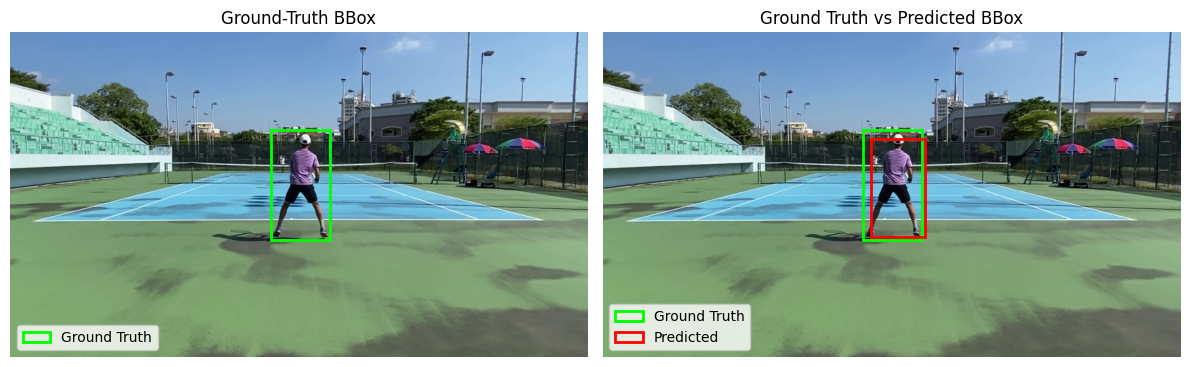

Sample diagnostics
- Mean |error| over [x, y, w, h]: 18.869487762451172
- IoU (GT vs Pred): 0.7422761917114258


In [42]:
def xywh_to_xyxy(box_xywh):
    x, y, w, h = box_xywh
    return np.array([x, y, x + w, y + h], dtype=np.float32)

def compute_iou_xywh(box_a, box_b):
    a = xywh_to_xyxy(box_a)
    b = xywh_to_xyxy(box_b)

    inter_x1 = max(a[0], b[0])
    inter_y1 = max(a[1], b[1])
    inter_x2 = min(a[2], b[2])
    inter_y2 = min(a[3], b[3])

    inter_w = max(0.0, inter_x2 - inter_x1)
    inter_h = max(0.0, inter_y2 - inter_y1)
    inter_area = inter_w * inter_h

    area_a = max(0.0, a[2] - a[0]) * max(0.0, a[3] - a[1])
    area_b = max(0.0, b[2] - b[0]) * max(0.0, b[3] - b[1])
    union = area_a + area_b - inter_area

    if union <= 0:
        return 0.0
    return inter_area / union

l1_error = float(np.mean(np.abs(pred_bbox_px - gt_bbox)))
iou = float(compute_iou_xywh(gt_bbox, pred_bbox_px))

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(original_img)
rect_gt = patches.Rectangle(
    (gt_bbox[0], gt_bbox[1]), gt_bbox[2], gt_bbox[3],
    linewidth=2, edgecolor="lime", facecolor="none", label="Ground Truth"
 )
axes[0].add_patch(rect_gt)
axes[0].set_title("Ground-Truth BBox")
axes[0].axis("off")
axes[0].legend(loc="lower left")

axes[1].imshow(original_img)
rect_gt_2 = patches.Rectangle(
    (gt_bbox[0], gt_bbox[1]), gt_bbox[2], gt_bbox[3],
    linewidth=2, edgecolor="lime", facecolor="none", label="Ground Truth"
 )
rect_pred = patches.Rectangle(
    (pred_bbox_px[0], pred_bbox_px[1]), pred_bbox_px[2], pred_bbox_px[3],
    linewidth=2, edgecolor="red", facecolor="none", label="Predicted"
 )
axes[1].add_patch(rect_gt_2)
axes[1].add_patch(rect_pred)
axes[1].set_title("Ground Truth vs Predicted BBox")
axes[1].axis("off")
axes[1].legend(loc="lower left")

plt.tight_layout()
plt.show()

print("Sample diagnostics")
print("- Mean |error| over [x, y, w, h]:", l1_error)
print("- IoU (GT vs Pred):", iou)

## Evaluation

Calculate IoU for each sample and use it report mAP of the model.

In [43]:
# Evaluate bbox model on the full dataset (single-class, one GT + one prediction per image)

bbox_model.eval()

ious = []
l1_errors = []

with torch.no_grad():
    for i in range(len(dataset_for_model)):
        img_tensor_i, gt_bbox_norm_i = dataset_for_model[i]  # both in normalized [x, y, w, h]
        pred_bbox_norm_i = bbox_model(img_tensor_i.unsqueeze(0).to(device))[0].detach().cpu().numpy()
        pred_bbox_norm_i = np.clip(pred_bbox_norm_i, 0.0, 1.0)

        gt_bbox_norm_i = gt_bbox_norm_i.numpy()

        iou_i = compute_iou_xywh(gt_bbox_norm_i, pred_bbox_norm_i)
        l1_i = float(np.mean(np.abs(pred_bbox_norm_i - gt_bbox_norm_i)))

        ious.append(iou_i)
        l1_errors.append(l1_i)

ious = np.array(ious, dtype=np.float32)
l1_errors = np.array(l1_errors, dtype=np.float32)

# COCO-style IoU thresholds
iou_thresholds = np.arange(0.50, 0.96, 0.05)
ap_by_threshold = {float(t): float(np.mean(ious >= t)) for t in iou_thresholds}

map_50 = ap_by_threshold[0.5]
map_50_95 = float(np.mean(list(ap_by_threshold.values())))

print("Evaluation results")
print(f"- Num samples: {len(ious)}")
print(f"- Mean IoU: {float(np.mean(ious)):.4f}")
print(f"- Mean L1 error (normalized xywh): {float(np.mean(l1_errors)):.4f}")
print(f"- AP@0.50: {map_50:.4f}")
print(f"- mAP@0.50:0.95: {map_50_95:.4f}")

print("\nAP by IoU threshold:")
for t in iou_thresholds:
    print(f"  AP@{t:.2f}: {ap_by_threshold[float(t)]:.4f}")

Evaluation results
- Num samples: 2000
- Mean IoU: 0.7340
- Mean L1 error (normalized xywh): 0.0234
- AP@0.50: 0.9435
- mAP@0.50:0.95: 0.5282

AP by IoU threshold:
  AP@0.50: 0.9435
  AP@0.55: 0.9175
  AP@0.60: 0.8660
  AP@0.65: 0.7855
  AP@0.70: 0.6825
  AP@0.75: 0.5120
  AP@0.80: 0.3465
  AP@0.85: 0.1685
  AP@0.90: 0.0565
  AP@0.95: 0.0030
